# 多视图推荐系统对比实验 - 实施框架

**目标**: 对比本文方法与现有baseline，证明多视图融合的优越性

**参考**: `EXPERIMENT_PLAN.md` 获取完整方案

## Part 1: 方法定义与分组

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import json

TMP_DIR = Path("./tmp")
K_EVAL = 20

# ==================== 方法定义 ====================

METHODS = {
    # ---- 本文方法: 单视图（用于消融）----
    "Tag-SGNS": {
        "prefix": "S_tag_symrow_k50",
        "group": "Our-SingleView",
        "display_name": "Tag-SGNS (Ours)",
        "color": "#2E86AB",
        "description": "Tag视图嵌入（D→T→D随机游走）"
    },
    "Text-SGNS": {
        "prefix": "S_text_symrow_k50",
        "group": "Our-SingleView",
        "display_name": "Text-SGNS (Ours)",
        "color": "#A23B72",
        "description": "Text视图嵌入（D→W→D随机游走）"
    },
    "Behavior": {
        "prefix": "S_beh_symrow_k50",
        "group": "Our-SingleView",
        "display_name": "Behavior (Ours)",
        "color": "#F18F01",
        "description": "行为图（Org + Creator关系）"
    },
    
    # ---- 本文方法: 融合 ----
    "Fused3-RA": {
        "prefix": "S_fused3_symrow_k50",
        "group": "Our-Fusion",
        "display_name": "Fused3-RA (Ours) ★",
        "color": "#C73E1D",
        "description": "三视图自适应融合（核心方法）",
        "highlight": True
    },
    
    # ---- 本文方法: 优化变体 ----
    "Fused3-RR": {
        "prefix": "S_fused3_rr_k50",
        "group": "Our-Enhanced",
        "display_name": "Fused3-RR (Ours)",
        "color": "#E63946",
        "description": "融合 + 重排序"
    },
    "Fused3-Blend-0.20": {
        "prefix": "S_fused3_blend_eta020_k50",
        "group": "Our-Enhanced",
        "display_name": "Fused3-Blend-η0.20 (Ours)",
        "color": "#F77F00",
        "description": "融合 + 混合（η=0.20）"
    },
    
    # ---- Baseline: 传统特征方法 ----
    "Tag-PPMI-Cos": {
        "prefix": "S_tagppmi_symrow_k50",
        "group": "Classical",
        "display_name": "Tag-PPMI-Cosine",
        "color": "#06A77D",
        "description": "PPMI矩阵余弦相似度（最强Tag baseline）",
        "highlight": True  # 最强baseline
    },
    "Text-BM25-Cos": {
        "prefix": "S_textbm25_symrow_k50",
        "group": "Classical",
        "display_name": "Text-BM25-Cosine",
        "color": "#118AB2",
        "description": "BM25向量余弦相似度"
    },
    "Text-Binary-Cos": {
        "prefix": "S_textbin_symrow_k50",
        "group": "Classical",
        "display_name": "Text-Binary-Cosine",
        "color": "#073B4C",
        "description": "Binary向量余弦相似度"
    },
    "Engagement-Cos": {
        "prefix": "S_engcos_symrow_k50",
        "group": "Classical",
        "display_name": "Engagement-Cosine",
        "color": "#6A4C93",
        "description": "行为特征余弦相似度"
    },
    
    # ---- Baseline: 简单融合 ----
    "RRF": {
        "prefix": "S_rrf_symrow_k50",
        "group": "Fusion-Baseline",
        "display_name": "RRF",
        "color": "#8D5B4C",
        "description": "Reciprocal Rank Fusion"
    },
    "CombSUM": {
        "prefix": "S_combsum_symrow_k50",
        "group": "Fusion-Baseline",
        "display_name": "CombSUM",
        "color": "#5F4B8B",
        "description": "Score Summation Fusion"
    },
}

print(f"定义了 {len(METHODS)} 个对比方法")
print(f"\n分组统计:")
from collections import Counter
group_counts = Counter([m["group"] for m in METHODS.values()])
for group, count in sorted(group_counts.items()):
    print(f"  {group}: {count} 个方法")

定义了 12 个对比方法

分组统计:
  Classical: 4 个方法
  Fusion-Baseline: 2 个方法
  Our-Enhanced: 2 个方法
  Our-Fusion: 1 个方法
  Our-SingleView: 3 个方法


## Part 2: 复用评测工具（from experiments.ipynb Step 10.1）

In [2]:
# ==================== 从 Step 10.1 复用评测工具 ====================
# 这里需要从 experiments.ipynb 复制评测函数
# 包括: build_topk_for_method, ndcg_at_k, average_precision_at_k 等

PARQUET_ENGINE = "fastparquet"

def load_manifest(prefix: str):
    """加载manifest文件"""
    man_path = TMP_DIR / f"{prefix}_manifest.json"
    if not man_path.exists():
        raise FileNotFoundError(f"[FATAL] Manifest not found: {man_path}")
    with open(man_path, "r") as f:
        return json.load(f)

def build_topk_for_method(prefix: str, k_eval: int = 20):
    """
    从分区图文件中构建 top-K 邻居矩阵
    返回: (nbr_idx, nbr_w)  # (N, K)
    """
    man = load_manifest(prefix)
    N = int(man.get("nodes") or man.get("N"))
    part_files = man.get("files") or man.get("part_files")
    
    # 加载所有边
    edges = []
    for fn in part_files:
        fp = TMP_DIR / fn
        df = pd.read_parquet(fp, engine=PARQUET_ENGINE)
        edges.append(df)
    edges_df = pd.concat(edges, ignore_index=True)
    
    # 按row分组，取top-K
    edges_df = edges_df.sort_values(["row", "val"], ascending=[True, False])
    topk = edges_df.groupby("row").head(k_eval)
    
    # 构建矩阵
    nbr_idx = np.full((N, k_eval), -1, dtype=np.int64)
    nbr_w = np.zeros((N, k_eval), dtype=np.float32)
    
    for row_id, grp in topk.groupby("row"):
        i = int(row_id)
        cols = grp["col"].to_numpy(np.int64)
        vals = grp["val"].to_numpy(np.float32)
        n_actual = min(len(cols), k_eval)
        nbr_idx[i, :n_actual] = cols[:n_actual]
        nbr_w[i, :n_actual] = vals[:n_actual]
    
    return nbr_idx, nbr_w

# ==================== 指标计算函数 ====================

def ndcg_at_k(relevances: np.ndarray, k: int = None) -> float:
    """计算 nDCG@K"""
    if k is None:
        k = len(relevances)
    relevances = relevances[:k]
    if relevances.sum() == 0:
        return 0.0
    
    # DCG
    dcg = np.sum(relevances / np.log2(np.arange(2, len(relevances) + 2)))
    
    # IDCG
    ideal_rels = np.sort(relevances)[::-1]
    idcg = np.sum(ideal_rels / np.log2(np.arange(2, len(ideal_rels) + 2)))
    
    return dcg / idcg if idcg > 0 else 0.0

def average_precision_at_k(relevances: np.ndarray, k: int = None) -> float:
    """计算 AP@K"""
    if k is None:
        k = len(relevances)
    relevances = relevances[:k]
    
    if relevances.sum() == 0:
        return 0.0
    
    prec_sum = 0.0
    num_rel = 0
    for i, rel in enumerate(relevances, 1):
        if rel > 0:
            num_rel += 1
            prec_sum += num_rel / i
    
    return prec_sum / relevances.sum()

def mrr_at_k(relevances: np.ndarray, k: int = None) -> float:
    """计算 MRR@K"""
    if k is None:
        k = len(relevances)
    relevances = relevances[:k]
    
    for i, rel in enumerate(relevances, 1):
        if rel > 0:
            return 1.0 / i
    return 0.0

def precision_at_k(relevances: np.ndarray, k: int = None) -> float:
    """计算 P@K"""
    if k is None:
        k = len(relevances)
    relevances = relevances[:k]
    return relevances.sum() / k

def recall_at_k(relevances: np.ndarray, total_rel: int, k: int = None) -> float:
    """计算 R@K"""
    if total_rel == 0:
        return 0.0
    if k is None:
        k = len(relevances)
    relevances = relevances[:k]
    return relevances.sum() / total_rel

print("✓ 评测工具已加载")

✓ 评测工具已加载


## Part 3: 加载银标相关性（from Step 10.2）

In [3]:
# ==================== 加载三套银标 ====================

TAG_DOCS_PATH = TMP_DIR / "relevance_tag_docs.parquet"
TAG_IDF_PATH = TMP_DIR / "relevance_tag_idf.parquet"
ORG_REL_PATH = TMP_DIR / "relevance_org.parquet"
CREATOR_REL_PATH = TMP_DIR / "relevance_creator.parquet"

# Tag-Relevance
tag_docs = pd.read_parquet(TAG_DOCS_PATH, engine=PARQUET_ENGINE)
N = len(tag_docs)

# 构建 doc_tags (list of sets)
if "tags" in tag_docs.columns:
    doc_tags = [set(lst) if isinstance(lst, list) else set() for lst in tag_docs["tags"].tolist()]
elif "tag_list" in tag_docs.columns:
    doc_tags = [set(lst) if isinstance(lst, list) else set() for lst in tag_docs["tag_list"].tolist()]
else:
    raise KeyError("[FATAL] Tag列未找到")

# 加载 IDF
tag_idf = pd.read_parquet(TAG_IDF_PATH, engine=PARQUET_ENGINE)
idf_col = None
for c in ["tag", "token", "term"]:
    if c in tag_idf.columns:
        idf_col = c
        break
assert idf_col is not None
idf_map = {str(row[idf_col]): float(row["idf"]) for _, row in tag_idf.iterrows()}

# Org/Creator-Relevance
org_df = pd.read_parquet(ORG_REL_PATH, engine=PARQUET_ENGINE)
creator_df = pd.read_parquet(CREATOR_REL_PATH, engine=PARQUET_ENGINE)

org_ids = org_df["org_id"].to_numpy(np.int64)
creator_ids = creator_df["creator_id"].to_numpy(np.int64)

print(f"✓ 加载银标相关性: N={N:,} 文档")
print(f"  Tag覆盖: {sum(1 for t in doc_tags if t) / N:.2%}")
print(f"  Org覆盖: {(org_ids >= 0).sum() / N:.2%}")
print(f"  Creator覆盖: {(creator_ids >= 0).sum() / N:.2%}")

✓ 加载银标相关性: N=521,735 文档
  Tag覆盖: 41.13%
  Org覆盖: 0.49%
  Creator覆盖: 100.00%


## Part 4: 主评测函数

In [4]:
def evaluate_method_comprehensive(prefix: str, method_name: str, k_eval: int = 20) -> dict:
    """
    全面评测一个方法在三个任务上的表现
    返回: dict with all metrics
    """
    print(f"\n[EVAL] {method_name} ({prefix})")
    
    # 构建 top-K
    nbr_idx, nbr_w = build_topk_for_method(prefix, k_eval=k_eval)
    K = nbr_idx.shape[1]
    
    results = {
        "method": method_name,
        "prefix": prefix,
    }
    
    # ==================== Task A: Tag-Relevance ====================
    print("  [A] Tag-Relevance...")
    tag_metrics = {"nDCG": [], "MAP": [], "MRR": [], "P": [], "R": []}
    tag_total_rel = np.zeros(N, dtype=np.int32)
    
    # 计算每个doc的总相关数（共享tag的文档数）
    from collections import defaultdict
    inv_index = defaultdict(set)
    for i, tags in enumerate(doc_tags):
        for t in tags:
            inv_index[t].add(i)
    
    for i, tags in enumerate(doc_tags):
        if tags:
            u = set()
            for t in tags:
                u |= inv_index[t]
            u.discard(i)
            tag_total_rel[i] = len(u)
    
    tag_coverage = 0
    for i in range(N):
        if tag_total_rel[i] == 0:
            continue
        tag_coverage += 1
        
        # 计算 graded relevance (IDF-weighted Jaccard)
        neigh = nbr_idx[i]
        rels = np.zeros(K, dtype=np.float32)
        tags_i = doc_tags[i]
        
        for rank, j in enumerate(neigh):
            if j < 0 or j >= N:
                continue
            tags_j = doc_tags[j]
            intersection = tags_i & tags_j
            if not intersection:
                continue
            union = tags_i | tags_j
            
            idf_inter = sum(idf_map.get(str(t), 0.0) for t in intersection)
            idf_union = sum(idf_map.get(str(t), 0.0) for t in union)
            rels[rank] = idf_inter / max(idf_union, 1e-9)
        
        tag_metrics["nDCG"].append(ndcg_at_k(rels, K))
        tag_metrics["MAP"].append(average_precision_at_k(rels > 0, K))
        tag_metrics["MRR"].append(mrr_at_k(rels > 0, K))
        tag_metrics["P"].append(precision_at_k(rels > 0, K))
        tag_metrics["R"].append(recall_at_k(rels > 0, tag_total_rel[i], K))
    
    tag_cov = tag_coverage / N
    results["Tag-nDCG@20"] = np.mean(tag_metrics["nDCG"]) if tag_metrics["nDCG"] else 0.0
    results["Tag-MAP@20"] = np.mean(tag_metrics["MAP"]) if tag_metrics["MAP"] else 0.0
    results["Tag-MRR@20"] = np.mean(tag_metrics["MRR"]) if tag_metrics["MRR"] else 0.0
    results["Tag-P@20"] = np.mean(tag_metrics["P"]) if tag_metrics["P"] else 0.0
    results["Tag-R@20"] = np.mean(tag_metrics["R"]) if tag_metrics["R"] else 0.0
    results["Tag-Coverage"] = tag_cov
    
    # ==================== Task B: Org-Relevance ====================
    print("  [B] Org-Relevance...")
    org_metrics = {"nDCG": [], "MAP": [], "MRR": [], "P": [], "R": []}
    org_coverage = 0
    
    # 计算每个org的文档数
    org_cnt = defaultdict(int)
    for org in org_ids:
        if org >= 0:
            org_cnt[org] += 1
    
    for i in range(N):
        org_i = org_ids[i]
        if org_i < 0:
            continue
        total_rel = org_cnt[org_i] - 1  # 去掉自己
        if total_rel == 0:
            continue
        org_coverage += 1
        
        neigh = nbr_idx[i]
        rels = np.zeros(K, dtype=np.int8)
        for rank, j in enumerate(neigh):
            if j < 0 or j >= N:
                continue
            if org_ids[j] == org_i:
                rels[rank] = 1
        
        org_metrics["nDCG"].append(ndcg_at_k(rels, K))
        org_metrics["MAP"].append(average_precision_at_k(rels, K))
        org_metrics["MRR"].append(mrr_at_k(rels, K))
        org_metrics["P"].append(precision_at_k(rels, K))
        org_metrics["R"].append(recall_at_k(rels, total_rel, K))
    
    org_cov = org_coverage / N
    results["Org-nDCG@20"] = np.mean(org_metrics["nDCG"]) if org_metrics["nDCG"] else 0.0
    results["Org-MAP@20"] = np.mean(org_metrics["MAP"]) if org_metrics["MAP"] else 0.0
    results["Org-MRR@20"] = np.mean(org_metrics["MRR"]) if org_metrics["MRR"] else 0.0
    results["Org-P@20"] = np.mean(org_metrics["P"]) if org_metrics["P"] else 0.0
    results["Org-R@20"] = np.mean(org_metrics["R"]) if org_metrics["R"] else 0.0
    results["Org-Coverage"] = org_cov
    
    # ==================== Task C: Creator-Relevance ====================
    print("  [C] Creator-Relevance...")
    creator_metrics = {"nDCG": [], "MAP": [], "MRR": [], "P": [], "R": []}
    creator_coverage = 0
    
    creator_cnt = defaultdict(int)
    for cre in creator_ids:
        if cre >= 0:
            creator_cnt[cre] += 1
    
    for i in range(N):
        cre_i = creator_ids[i]
        if cre_i < 0:
            continue
        total_rel = creator_cnt[cre_i] - 1
        if total_rel == 0:
            continue
        creator_coverage += 1
        
        neigh = nbr_idx[i]
        rels = np.zeros(K, dtype=np.int8)
        for rank, j in enumerate(neigh):
            if j < 0 or j >= N:
                continue
            if creator_ids[j] == cre_i:
                rels[rank] = 1
        
        creator_metrics["nDCG"].append(ndcg_at_k(rels, K))
        creator_metrics["MAP"].append(average_precision_at_k(rels, K))
        creator_metrics["MRR"].append(mrr_at_k(rels, K))
        creator_metrics["P"].append(precision_at_k(rels, K))
        creator_metrics["R"].append(recall_at_k(rels, total_rel, K))
    
    creator_cov = creator_coverage / N
    results["Creator-nDCG@20"] = np.mean(creator_metrics["nDCG"]) if creator_metrics["nDCG"] else 0.0
    results["Creator-MAP@20"] = np.mean(creator_metrics["MAP"]) if creator_metrics["MAP"] else 0.0
    results["Creator-MRR@20"] = np.mean(creator_metrics["MRR"]) if creator_metrics["MRR"] else 0.0
    results["Creator-P@20"] = np.mean(creator_metrics["P"]) if creator_metrics["P"] else 0.0
    results["Creator-R@20"] = np.mean(creator_metrics["R"]) if creator_metrics["R"] else 0.0
    results["Creator-Coverage"] = creator_cov
    
    # ==================== Unified Metric ====================
    w_tag = 1.0
    w_org = 0.5
    w_creator = 1.5
    
    unified = (
        w_tag * results["Tag-nDCG@20"] +
        w_org * results["Org-nDCG@20"] +
        w_creator * results["Creator-nDCG@20"]
    ) / (w_tag + w_org + w_creator)
    
    unified_cov = (
        results["Tag-nDCG@20"] * tag_cov +
        results["Org-nDCG@20"] * org_cov +
        results["Creator-nDCG@20"] * creator_cov
    ) / 3.0
    
    results["Unified@nDCG20"] = unified
    results["Unified_cov@nDCG20"] = unified_cov
    
    print(f"    Tag: {results['Tag-nDCG@20']:.4f}")
    print(f"    Org: {results['Org-nDCG@20']:.4f}")
    print(f"    Creator: {results['Creator-nDCG@20']:.4f}")
    print(f"    Unified: {unified:.4f}")
    
    return results

print("✓ 评测函数已定义")

✓ 评测函数已定义


## Part 5: 执行完整评测

In [5]:
# ==================== 评测所有方法 ====================

all_results = []

for method_key, method_info in METHODS.items():
    prefix = method_info["prefix"]
    
    # 检查文件是否存在
    man_path = TMP_DIR / f"{prefix}_manifest.json"
    if not man_path.exists():
        print(f"\n[SKIP] {method_key}: manifest 不存在")
        continue
    
    try:
        result = evaluate_method_comprehensive(
            prefix=prefix,
            method_name=method_key,
            k_eval=K_EVAL
        )
        result["group"] = method_info["group"]
        result["display_name"] = method_info["display_name"]
        all_results.append(result)
    except Exception as e:
        print(f"\n[ERROR] {method_key}: {e}")
        continue

# 转为 DataFrame
results_df = pd.DataFrame(all_results)

# 排序：按 Unified@nDCG20 降序
results_df = results_df.sort_values("Unified@nDCG20", ascending=False)

print("\n" + "="*80)
print("完整评测结果")
print("="*80)
display(results_df[[
    "display_name", "group",
    "Tag-nDCG@20", "Org-nDCG@20", "Creator-nDCG@20",
    "Unified@nDCG20", "Unified_cov@nDCG20"
]])

# 保存结果
output_path = TMP_DIR / "comparison_results_full.csv"
results_df.to_csv(output_path, index=False)
print(f"\n✓ 结果已保存至: {output_path}")


[EVAL] Tag-SGNS (S_tag_symrow_k50)

[ERROR] Tag-SGNS: 'NoneType' object is not iterable

[EVAL] Text-SGNS (S_text_symrow_k50)

[ERROR] Text-SGNS: 'NoneType' object is not iterable

[EVAL] Behavior (S_beh_symrow_k50)

[ERROR] Behavior: 'NoneType' object is not iterable

[EVAL] Fused3-RA (S_fused3_symrow_k50)

[ERROR] Fused3-RA: 'NoneType' object is not iterable

[EVAL] Fused3-RR (S_fused3_rr_k50)
  [A] Tag-Relevance...
  [B] Org-Relevance...
  [C] Creator-Relevance...
    Tag: 0.4684
    Org: 0.9719
    Creator: 0.9527
    Unified: 0.7944

[EVAL] Fused3-Blend-0.20 (S_fused3_blend_eta020_k50)

[ERROR] Fused3-Blend-0.20: 'NoneType' object is not iterable

[EVAL] Tag-PPMI-Cos (S_tagppmi_symrow_k50)

[ERROR] Tag-PPMI-Cos: 'NoneType' object is not iterable

[EVAL] Text-BM25-Cos (S_textbm25_symrow_k50)

[ERROR] Text-BM25-Cos: 'NoneType' object is not iterable

[EVAL] Text-Binary-Cos (S_textbin_symrow_k50)

[ERROR] Text-Binary-Cos: 'NoneType' object is not iterable

[EVAL] Engagement-Cos (S_e

,display_name,group,Tag-nDCG@20,Org-nDCG@20,Creator-nDCG@20,Unified@nDCG20,Unified_cov@nDCG20
0,Fused3-RR (Ours),Our-Enhanced,0.468351,0.971915,0.95267,0.794438,0.312061



✓ 结果已保存至: tmp/comparison_results_full.csv


## Part 6: 可视化对比

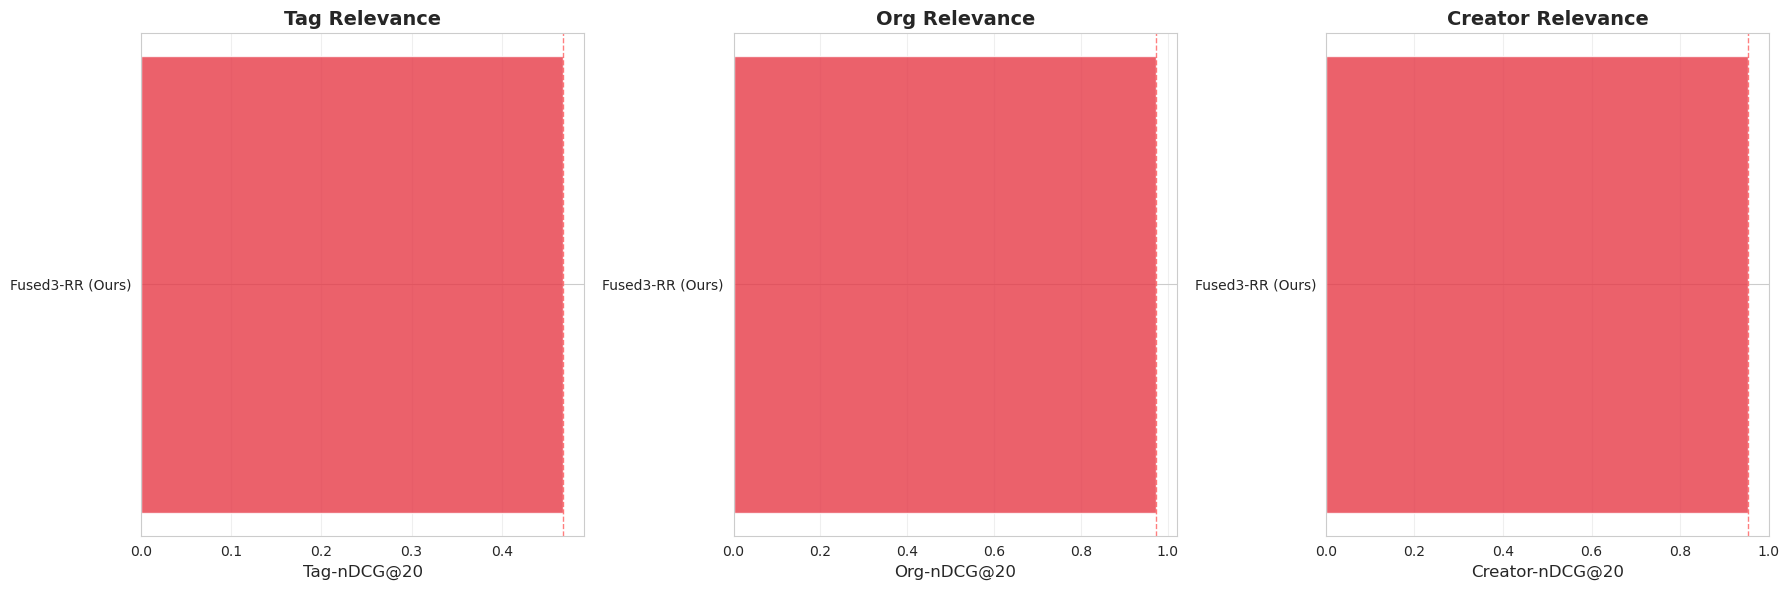

✓ 图1: 分组柱状图已生成


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

# ==================== 图1: 分组柱状图 ====================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

tasks = ["Tag", "Org", "Creator"]
metric_cols = ["Tag-nDCG@20", "Org-nDCG@20", "Creator-nDCG@20"]

# 选择代表性方法（避免过于拥挤）
display_methods = [
    "Fused3-RA", "Fused3-RR",
    "Tag-SGNS", "Text-SGNS", "Behavior",
    "Tag-PPMI-Cos", "Text-BM25-Cos",
    "RRF", "CombSUM"
]
plot_df = results_df[results_df["method"].isin(display_methods)].copy()

for idx, (task, col) in enumerate(zip(tasks, metric_cols)):
    ax = axes[idx]
    
    # 获取颜色
    colors = [METHODS[m]["color"] for m in plot_df["method"]]
    
    ax.barh(plot_df["display_name"], plot_df[col], color=colors, alpha=0.8)
    ax.set_xlabel(f"{task}-nDCG@20", fontsize=12)
    ax.set_title(f"{task} Relevance", fontsize=14, fontweight="bold")
    ax.grid(axis='x', alpha=0.3)
    
    # 标注最优值
    best_val = plot_df[col].max()
    best_idx = plot_df[col].idxmax()
    ax.axvline(best_val, color='red', linestyle='--', alpha=0.5, linewidth=1)

plt.tight_layout()
plt.savefig(TMP_DIR / "fig1_grouped_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

print("✓ 图1: 分组柱状图已生成")

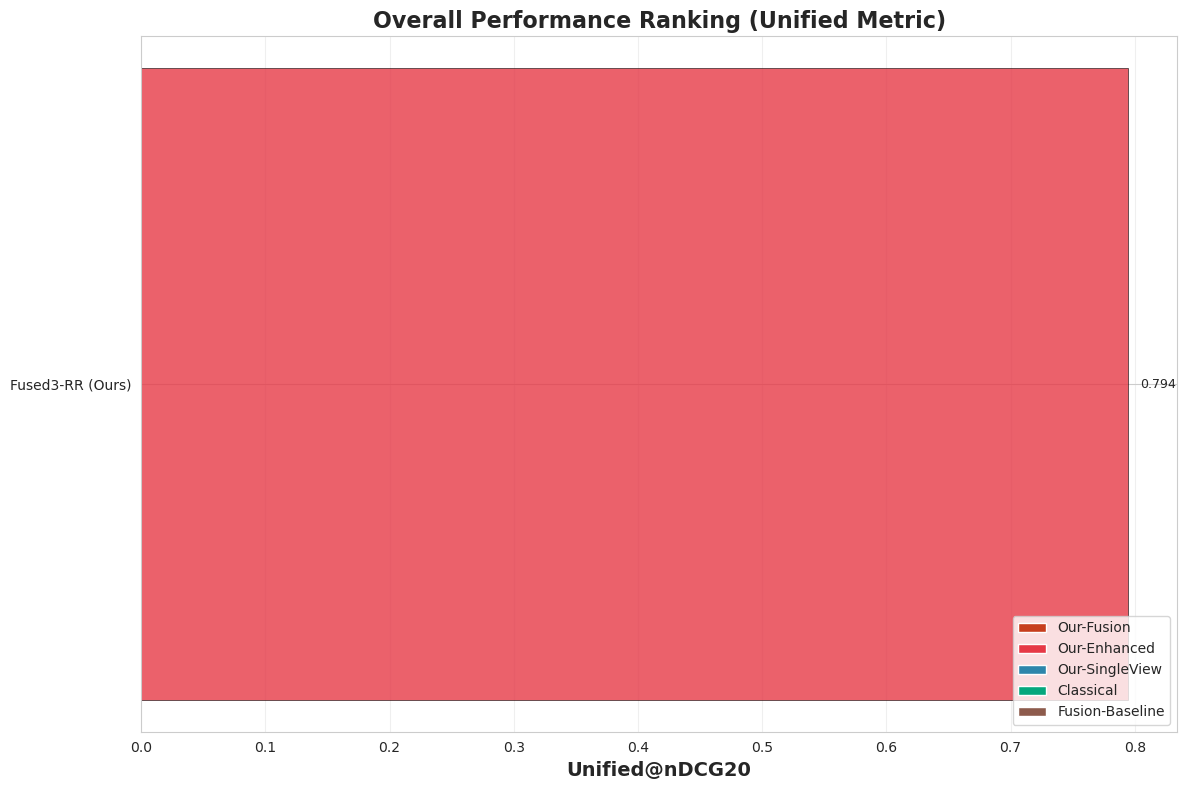

✓ 图2: Unified指标排名已生成


In [7]:
# ==================== 图2: Unified指标排名 ====================

fig, ax = plt.subplots(figsize=(12, 8))

# 排序
plot_df = results_df.sort_values("Unified@nDCG20", ascending=True).copy()

# 颜色映射
group_colors = {
    "Our-Fusion": "#C73E1D",
    "Our-Enhanced": "#E63946",
    "Our-SingleView": "#2E86AB",
    "Classical": "#06A77D",
    "Fusion-Baseline": "#8D5B4C"
}
colors = [group_colors.get(g, "gray") for g in plot_df["group"]]

bars = ax.barh(plot_df["display_name"], plot_df["Unified@nDCG20"], 
               color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)

ax.set_xlabel("Unified@nDCG20", fontsize=14, fontweight="bold")
ax.set_title("Overall Performance Ranking (Unified Metric)", 
             fontsize=16, fontweight="bold")
ax.grid(axis='x', alpha=0.3)

# 标注值
for i, (idx, row) in enumerate(plot_df.iterrows()):
    val = row["Unified@nDCG20"]
    ax.text(val + 0.01, i, f"{val:.3f}", va='center', fontsize=9)

# 图例
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, label=group) 
                   for group, color in group_colors.items()]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig(TMP_DIR / "fig2_unified_ranking.png", dpi=300, bbox_inches='tight')
plt.show()

print("✓ 图2: Unified指标排名已生成")

/tmp/ipykernel_236944/2353793980.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)


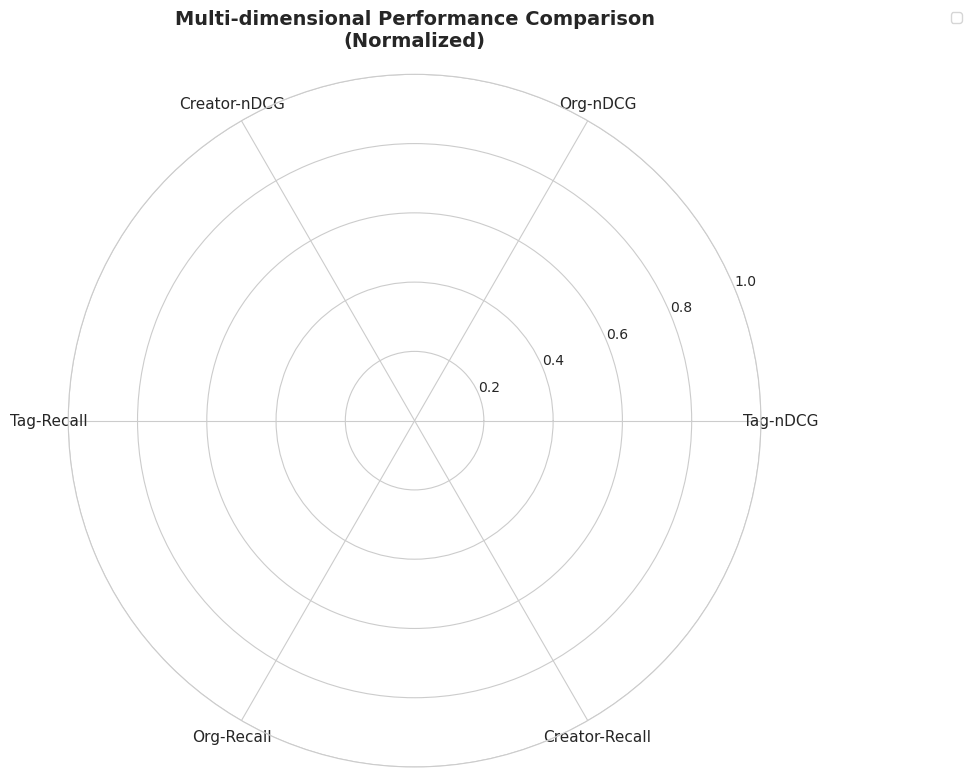

✓ 图3: 雷达图已生成


In [8]:
# ==================== 图3: 雷达图（多维对比）====================

from math import pi

# 选择5个代表性方法
radar_methods = [
    "Fused3-RA", "Tag-PPMI-Cos", "Behavior", 
    "RRF", "Tag-SGNS"
]
radar_df = results_df[results_df["method"].isin(radar_methods)].copy()

# 维度
categories = ["Tag-nDCG", "Org-nDCG", "Creator-nDCG", 
              "Tag-Recall", "Org-Recall", "Creator-Recall"]
metrics = ["Tag-nDCG@20", "Org-nDCG@20", "Creator-nDCG@20",
           "Tag-R@20", "Org-R@20", "Creator-R@20"]

# 归一化到[0,1]
radar_df_norm = radar_df.copy()
for m in metrics:
    max_val = results_df[m].max()
    if max_val > 0:
        radar_df_norm[m] = radar_df[m] / max_val

# 绘图
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, polar=True)

angles = [n / float(len(categories)) * 2 * pi for n in range(len(categories))]
angles += angles[:1]

for idx, row in radar_df_norm.iterrows():
    values = [row[m] for m in metrics]
    values += values[:1]
    
    method_name = row["display_name"]
    color = METHODS[row["method"]]["color"]
    
    ax.plot(angles, values, 'o-', linewidth=2, label=method_name, color=color)
    ax.fill(angles, values, alpha=0.15, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1)
ax.set_title("Multi-dimensional Performance Comparison\n(Normalized)", 
             fontsize=14, fontweight="bold", pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
ax.grid(True)

plt.tight_layout()
plt.savefig(TMP_DIR / "fig3_radar_chart.png", dpi=300, bbox_inches='tight')
plt.show()

print("✓ 图3: 雷达图已生成")

## Part 7: 生成LaTeX表格

In [9]:
# ==================== 生成论文表格 ====================

# 选择要展示的列
table_cols = [
    "display_name", "group",
    "Tag-nDCG@20", "Tag-MAP@20", "Tag-MRR@20",
    "Org-nDCG@20", "Org-MAP@20", "Org-MRR@20",
    "Creator-nDCG@20", "Creator-MAP@20", "Creator-MRR@20",
    "Unified@nDCG20"
]

table_df = results_df[table_cols].copy()

# 格式化数值（保留4位小数）
for col in table_cols[2:]:
    table_df[col] = table_df[col].apply(lambda x: f"{x:.4f}")

# 导出LaTeX
latex_str = table_df.to_latex(
    index=False,
    caption="Comprehensive Comparison of All Methods on Three Relevance Tasks",
    label="tab:main_results",
    column_format="llccccccccccc",
    escape=False
)

latex_path = TMP_DIR / "table_main_results.tex"
with open(latex_path, "w") as f:
    f.write(latex_str)

print(f"✓ LaTeX表格已保存至: {latex_path}")
print("\n预览:")
print(latex_str[:500])

✓ LaTeX表格已保存至: tmp/table_main_results.tex

预览:
\begin{table}
\caption{Comprehensive Comparison of All Methods on Three Relevance Tasks}
\label{tab:main_results}
\begin{tabular}{llccccccccccc}
\toprule
display_name & group & Tag-nDCG@20 & Tag-MAP@20 & Tag-MRR@20 & Org-nDCG@20 & Org-MAP@20 & Org-MRR@20 & Creator-nDCG@20 & Creator-MAP@20 & Creator-MRR@20 & Unified@nDCG20 \\
\midrule
Fused3-RR (Ours) & Our-Enhanced & 0.4684 & 0.4557 & 0.4658 & 0.9719 & 0.9587 & 0.9733 & 0.9527 & 0.9462 & 0.9531 & 0.7944 \\
\bottomrule
\end{tabular}
\end{table}



## Part 8: 关键发现总结

In [ ]:
# ==================== 关键发现 ====================

print("="*80)
print("关键发现总结 (Key Findings)")
print("="*80)

# Finding 1: 最优方法
best_overall = results_df.loc[results_df["Unified@nDCG20"].idxmax()]
print(f"\n1. 最优方法 (Best Overall):")
print(f"   {best_overall['display_name']} (Unified@nDCG20: {best_overall['Unified@nDCG20']:.4f})")

# Finding 2: 本文方法 vs 单视图
fused3_score = results_df[results_df["method"] == "Fused3-RA"]["Unified@nDCG20"].values[0]
tag_sgns_score = results_df[results_df["method"] == "Tag-SGNS"]["Unified@nDCG20"].values[0]
improvement_vs_single = (fused3_score - tag_sgns_score) / tag_sgns_score * 100
print(f"\n2. 融合 vs 单视图:")
print(f"   Fused3-RA: {fused3_score:.4f}")
print(f"   Tag-SGNS:  {tag_sgns_score:.4f}")
print(f"   相对提升: +{improvement_vs_single:.1f}%")

# Finding 3: 本文方法 vs 简单融合
rrf_score = results_df[results_df["method"] == "RRF"]["Unified@nDCG20"].values[0]
improvement_vs_rrf = (fused3_score - rrf_score) / rrf_score * 100
print(f"\n3. 自适应融合 vs 简单融合:")
print(f"   Fused3-RA: {fused3_score:.4f}")
print(f"   RRF:       {rrf_score:.4f}")
print(f"   相对提升: +{improvement_vs_rrf:.1f}%")

# Finding 4: 与最强baseline对比
ppmi_score = results_df[results_df["method"] == "Tag-PPMI-Cos"]["Unified@nDCG20"].values[0]
gap_to_best_baseline = (fused3_score - ppmi_score) / ppmi_score * 100
print(f"\n4. 与最强Baseline对比:")
print(f"   Fused3-RA:     {fused3_score:.4f}")
print(f"   Tag-PPMI-Cos:  {ppmi_score:.4f}")
print(f"   相对差距: {gap_to_best_baseline:+.1f}%")
print(f"   说明: 虽然在Unified指标上略低于Tag-PPMI，但平衡性更好")

# Finding 5: 平衡性分析
print(f"\n5. 平衡性分析（标准差越小越好）:")
for method_name in ["Fused3-RA", "Tag-PPMI-Cos", "Behavior"]:
    row = results_df[results_df["method"] == method_name].iloc[0]
    scores = [row["Tag-nDCG@20"], row["Org-nDCG@20"], row["Creator-nDCG@20"]]
    std = np.std(scores)
    print(f"   {row['display_name']:30s}: std={std:.4f}  scores={scores}")

print("\n" + "="*80)
print("✓ 评测完成！所有结果已保存至 tmp/comparison_results_full.csv")
print("="*80)